In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
cars_data = pd.read_csv('Cardetails.csv')
cars_data

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [3]:
cars_data.drop(columns=['torque'], inplace=True)

In [4]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [5]:
cars_data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
seats            221
dtype: int64

In [6]:
cars_data.dropna(inplace=True)

In [7]:
cars_data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [8]:
cars_data.duplicated().sum()

np.int64(1189)

In [9]:
cars_data.drop_duplicates(inplace=True)

In [10]:
cars_data.shape

(6718, 12)

In [11]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   str    
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   str    
 5   seller_type    6718 non-null   str    
 6   transmission   6718 non-null   str    
 7   owner          6718 non-null   str    
 8   mileage        6718 non-null   str    
 9   engine         6718 non-null   str    
 10  max_power      6718 non-null   str    
 11  seats          6718 non-null   float64
dtypes: float64(1), int64(3), str(8)
memory usage: 1.2 MB


In [12]:
def clean_data(value):
    if value is None or str(value).strip() == '':
        return ''
        
    # Extract the first word
    first_word = str(value).split(' ')[0].strip()
    
    # Try to make it a number; if it fails, keep it as text
    try:
        return float(first_word)
    except ValueError:
        return first_word

In [13]:
cars_data['name'] = cars_data['name'].apply(clean_data)
cars_data['mileage'] = cars_data['mileage'].apply(clean_data)
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)
cars_data['engine'] = cars_data['engine'].apply(clean_data)

In [14]:
cars_data.head(8)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.0,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.0,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.0,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37.0,4.0


In [15]:
cars_data['max_power'] = pd.to_numeric(cars_data['max_power'].astype(str).str.replace(' bhp', '').str.strip(), errors='coerce')

In [16]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   str    
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   str    
 5   seller_type    6718 non-null   str    
 6   transmission   6718 non-null   str    
 7   owner          6718 non-null   str    
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6718 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 945.4 KB


In [17]:
cars_data['name'].unique()

<ArrowStringArray>
[       'Maruti',         'Skoda',         'Honda',       'Hyundai',
        'Toyota',          'Ford',       'Renault',      'Mahindra',
          'Tata',     'Chevrolet',        'Datsun',          'Jeep',
 'Mercedes-Benz',    'Mitsubishi',          'Audi',    'Volkswagen',
           'BMW',        'Nissan',         'Lexus',        'Jaguar',
          'Land',            'MG',         'Volvo',        'Daewoo',
           'Kia',          'Fiat',         'Force',    'Ambassador',
         'Ashok',         'Isuzu',          'Opel']
Length: 31, dtype: str

In [18]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
cols_to_encode = ['name', 'fuel', 'seller_type', 'owner', 'transmission']

for col in cols_to_encode:
    encoders[col] = LabelEncoder()
    cars_data[col] = encoders[col].fit_transform(cars_data[col])

In [19]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,20,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0
1,26,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,10,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0
3,11,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,5.0
4,20,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,5.0


In [20]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   int64  
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   int64  
 5   seller_type    6718 non-null   int64  
 6   transmission   6718 non-null   int64  
 7   owner          6718 non-null   int64  
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6718 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 682.3 KB


In [21]:
cars_data.dropna(inplace = True)

In [22]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   int64  
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   int64  
 5   seller_type    6717 non-null   int64  
 6   transmission   6717 non-null   int64  
 7   owner          6717 non-null   int64  
 8   mileage        6717 non-null   float64
 9   engine         6717 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6717 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 682.2 KB


In [23]:
for col in cols_to_encode:
    print('Unique Values of ' +col)
    print(cars_data[col].unique())
    print('======================')

Unique Values of name
[20 26 10 11 28  9 25 19 27  4  6 14 21 22  2 29  3 23 17 13 16 18 30  5
 15  7  8  0  1 12 24]
Unique Values of fuel
[1 3 2 0]
Unique Values of seller_type
[1 0 2]
Unique Values of owner
[0 2 4 1 3]
Unique Values of transmission
[1 0]


In [24]:
from sklearn.metrics import r2_score

# 1. Initialize the model
lr = LinearRegression()

# 2. Separate features and target
feature_cols = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 
                'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
X = cars_data[feature_cols]
y = cars_data['selling_price']

# 3. Split the data exactly as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Apply log transformation to the training target variable
y_train_log = np.log1p(y_train)

# 5. Fit the linear regression model using the log-scaled target
lr.fit(X_train, y_train_log)

# 6. Predict on the test features (this outputs log-scaled values)
y_pred_log = lr.predict(X_test)

# 7. Convert the log predictions back to original prices (Rupees)
y_pred = np.expm1(y_pred_log)

# 8. Check your new R² score
r2 = r2_score(y_test, y_pred)
print(f"New R² Score with Log Transform: {r2:.4f}")

New R² Score with Log Transform: 0.8560


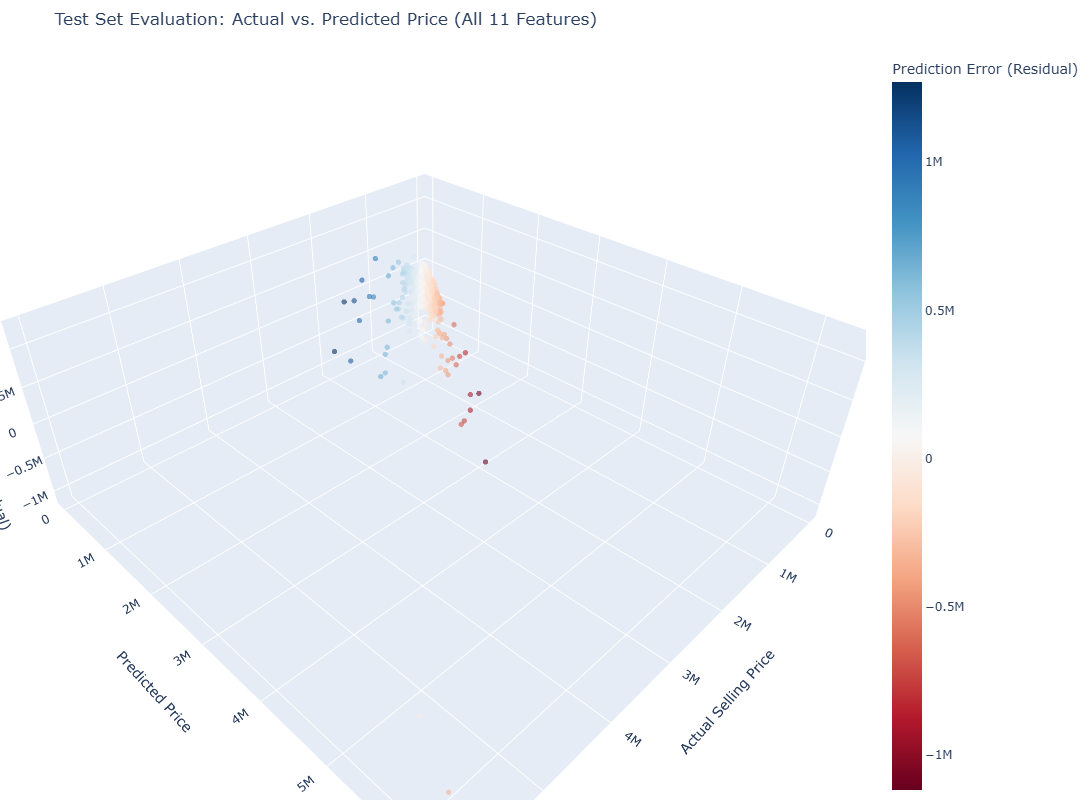

In [25]:
import plotly.express as px

test_results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

# 3. Calculate the prediction error (Residual)
test_results['Error'] = test_results['Actual Price'] - test_results['Predicted Price']

# 4. Plot the 3D chart using the new test_results DataFrame
fig = px.scatter_3d(
    test_results,
    x='Actual Price',
    y='Predicted Price',
    z='Error',
    color='Error',
    color_continuous_scale='RdBu',
    opacity=0.6,
    title='Test Set Evaluation: Actual vs. Predicted Price (All 11 Features)',
    labels={
        'Actual Price': 'Actual Selling Price',
        'Predicted Price': 'Predicted Price',
        'Error': 'Prediction Error (Residual)'
    }
)
fig.update_layout(
    width=1000, 
    height=800,
    margin=dict(l=0, r=0, b=0, t=50) 
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [26]:
import pickle

# Save the trained model
with open("car_price_model.pkl", "wb") as f:
    pickle.dump(lr, f)

# Save the encoders dictionary
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [27]:
X_test

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
7039,4,2015,155000,1,1,0,0,14.81,1998.0,163.70,5.0
5031,20,2017,15381,1,1,1,0,24.30,1248.0,88.50,5.0
2807,27,2012,12000,3,1,1,0,16.84,1193.0,64.40,5.0
1834,28,2018,60000,1,1,0,0,15.04,2755.0,174.50,7.0
4945,14,2017,69123,1,0,1,0,17.10,1956.0,170.00,5.0
...,...,...,...,...,...,...,...,...,...,...,...
5173,10,2013,100000,1,1,1,0,25.80,1498.0,98.60,5.0
462,11,2015,35000,3,1,1,0,18.60,1197.0,81.83,5.0
1931,11,2017,60000,3,1,1,0,20.30,998.0,68.05,5.0
1673,11,2015,48000,1,1,1,2,19.67,1582.0,126.20,5.0


In [28]:
y_test

7039     450000
5031     800000
2807      75000
1834    3200000
4945    1650000
         ...   
5173     325000
462      600000
1931     300000
1673    1300000
962      305000
Name: selling_price, Length: 1344, dtype: int64

In [29]:
y_pred

array([1288113.45563229,  617596.35411286,  223879.43143732, ...,
        406310.76142677,  683349.34623289,  215780.81665137],
      shape=(1344,))

In [35]:
print("--- Car Name Codes ---")
for code, brand in enumerate(encoders['fuel'].classes_):
    print(f"Code {code} -> {brand}")

--- Car Name Codes ---
Code 0 -> CNG
Code 1 -> Diesel
Code 2 -> LPG
Code 3 -> Petrol
